### Phase 1: Foundation & Preprocessing.

#### 1. Initial Setup and Memory Optimization

In [28]:
import pandas as pd
import numpy as np

df = pd.read_csv('data\Crime_Data_from_2020_to_Present.csv')

def optimize_memory(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
    return df

df = optimize_memory(df)

#### 2. Handling Missing Values and Column Drops

In [29]:
cols_to_drop = ['DR_NO', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Cross Street', 'Mocodes']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

df['Vict Sex'] = df['Vict Sex'].fillna('X')
df['Vict Descent'] = df['Vict Descent'].fillna('X')
df['Weapon Used Cd'] = df['Weapon Used Cd'].fillna(0) 

df.dropna(subset=['LAT', 'LON', 'Vict Age'], inplace=True)

#### 3. Temporal Feature Engineering

In [30]:
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])
df['Month'] = df['DATE OCC'].dt.month
df['DayOfWeek'] = df['DATE OCC'].dt.dayofweek
df['Year'] = df['DATE OCC'].dt.year

df['Hour'] = (df['TIME OCC'] // 100).astype(int)

df['hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

df['is_weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

C:\Users\aryam\AppData\Local\Temp\ipykernel_18984\1595819174.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])


#### 4. Categorical Encoding (Target Preparation)

In [31]:
from sklearn.preprocessing import LabelEncoder

le_area = LabelEncoder()
df['AREA_CODE'] = le_area.fit_transform(df['AREA NAME'])

le_crm = LabelEncoder()
df['CRM_TYPE_CODE'] = le_crm.fit_transform(df['Crm Cd Desc'])

#### 5.Data Quality Analysis Function

In [32]:
def generate_quality_report(df):
    report = pd.DataFrame({
        'Column': df.columns,
        'Data Type': df.dtypes.values,
        'Missing Values': df.isnull().sum().values,
        '% Missing': (df.isnull().sum().values / len(df)) * 100,
        'Unique Values': df.nunique().values,
        'Min Value': [df[col].min() if np.issubdtype(df[col].dtype, np.number) else 'N/A' for col in df.columns],
        'Max Value': [df[col].max() if np.issubdtype(df[col].dtype, np.number) else 'N/A' for col in df.columns]
    })
    
    return report.sort_values(by='% Missing', ascending=False)

quality_report = generate_quality_report(df)
print("LAPD Crime Data Quality Report")
print(quality_report)

LAPD Crime Data Quality Report
            Column       Data Type  Missing Values  % Missing  Unique Values  \
15     Weapon Desc          object          677744  67.437818             79   
13     Premis Desc          object             588   0.058508            306   
12       Premis Cd         float32              16   0.001592            314   
18        Crm Cd 1         float32              11   0.001095            142   
16          Status          object               1   0.000100              6   
3             AREA            int8               0   0.000000             21   
0        Date Rptd          object               0   0.000000           1896   
6         Part 1-2            int8               0   0.000000              2   
5      Rpt Dist No           int16               0   0.000000           1210   
7           Crm Cd           int16               0   0.000000            140   
8      Crm Cd Desc          object               0   0.000000            140   
10       

#### 6.Outlier Detection (Statistical Proof)

In [33]:
def check_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

age_outliers, low, high = check_outliers(df, 'Vict Age')
print(f"Vict Age Outliers: {age_outliers} (Values outside {low:.1f} - {high:.1f})")

Vict Age Outliers: 1 (Values outside -66.0 - 110.0)


#### 7.Visualizing Data Distribution

C:\Users\aryam\AppData\Local\Temp\ipykernel_18984\1448517900.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='DayOfWeek', data=df, palette='viridis')


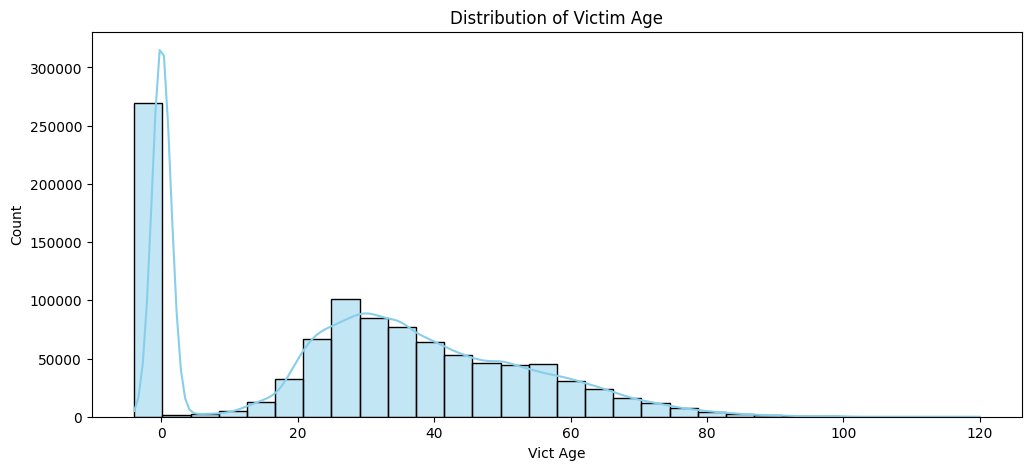

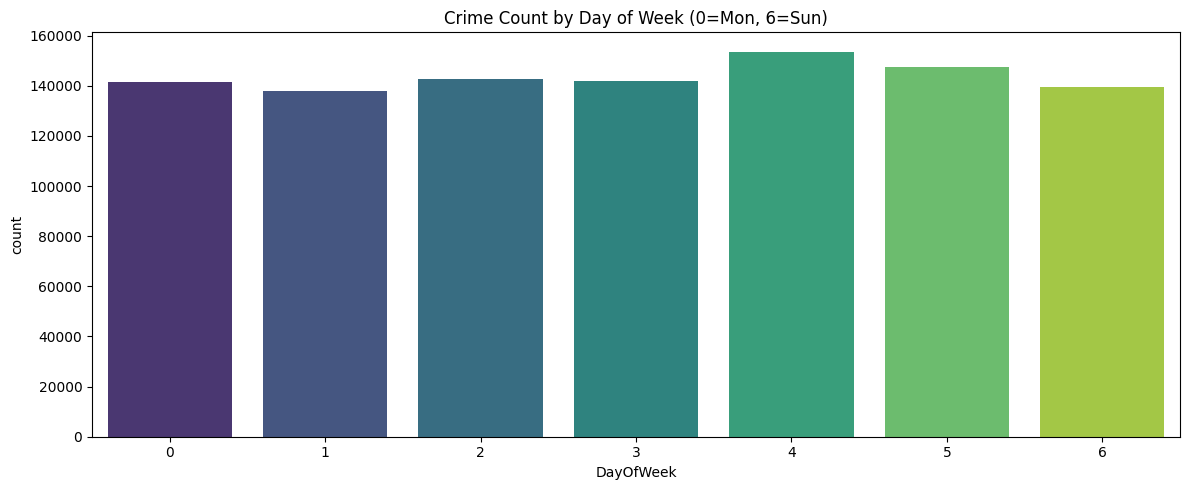

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# plt.subplot(1, 2)
sns.histplot(df['Vict Age'],bins=30, kde=True, color='skyblue')
plt.title('Distribution of Victim Age')

plt.figure(figsize=(12, 5))
# plt.subplot(1, 2)
sns.countplot(x='DayOfWeek', data=df, palette='viridis')
plt.title('Crime Count by Day of Week (0=Mon, 6=Sun)')

plt.tight_layout()
plt.show()

#### Saving the Cleaned Dataset

In [35]:
# # Remove placeholder ages and 'Null Island' GPS coordinates
# df = df[df['Vict Age'] > 0]
# df = df[(df['LAT'] != 0) & (df['LON'] != 0)]

# # Optimize the Date conversion to avoid the UserWarning
# df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], format='%m/%d/%Y %I:%M:%S %p')

In [36]:
# Calculate the median age excluding the 0s
median_age = df[df['Vict Age'] > 0]['Vict Age'].median()

# Replace 0 or negative ages with the median
df['Vict Age'] = df['Vict Age'].apply(lambda x: median_age if x <= 0 else x)

In [37]:
# Create a flag for missing GPS data
df['is_gps_missing'] = ((df['LAT'] == 0) & (df['LON'] == 0)).astype(int)

# Optional: Replace 0,0 with the center of Los Angeles so it doesn't break clustering
# LA Center approx: 34.0522, -118.2437
df.loc[df['is_gps_missing'] == 1, 'LAT'] = 34.0522
df.loc[df['is_gps_missing'] == 1, 'LON'] = -118.2437

In [38]:
df['Weapon Desc'] = df['Weapon Desc'].fillna('UNKNOWN')
df['Premis Desc'] = df['Premis Desc'].fillna('UNKNOWN')

In [39]:
import os

# Using a relative path that starts from your current project root
output_path = 'data/cleaned/cleaned_crime_data.csv'

# Create the folder if it doesn't exist
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Save the dataframe
df.to_csv(output_path, index=False)

print(f"File saved! Check your sidebar under: {output_path}")
print(f"Final Row Count: {len(df)}")

File saved! Check your sidebar under: data/cleaned/cleaned_crime_data.csv
Final Row Count: 1004991


#### Visualizing the "Fixed" Age Distribution

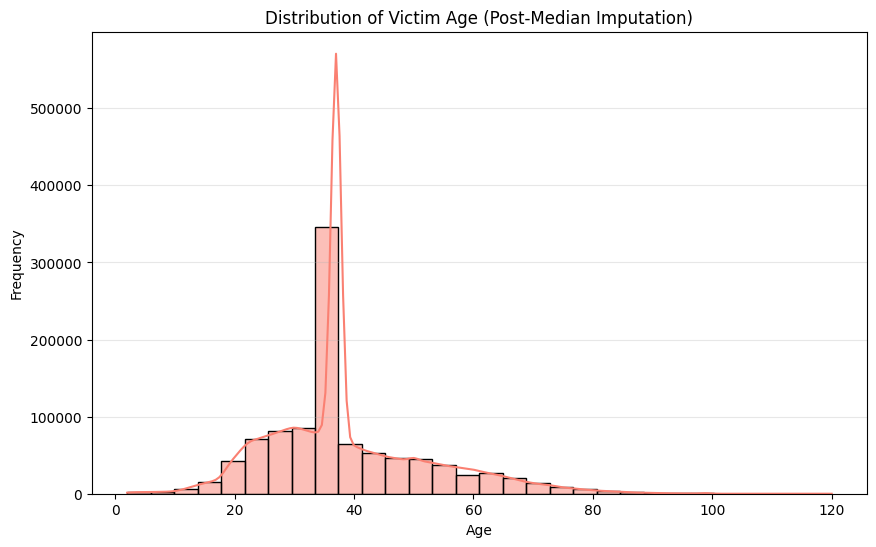

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Vict Age'], bins=30, kde=True, color='salmon')
plt.title('Distribution of Victim Age (Post-Median Imputation)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

#### Visualizing Geospatial Density (Heatmap)

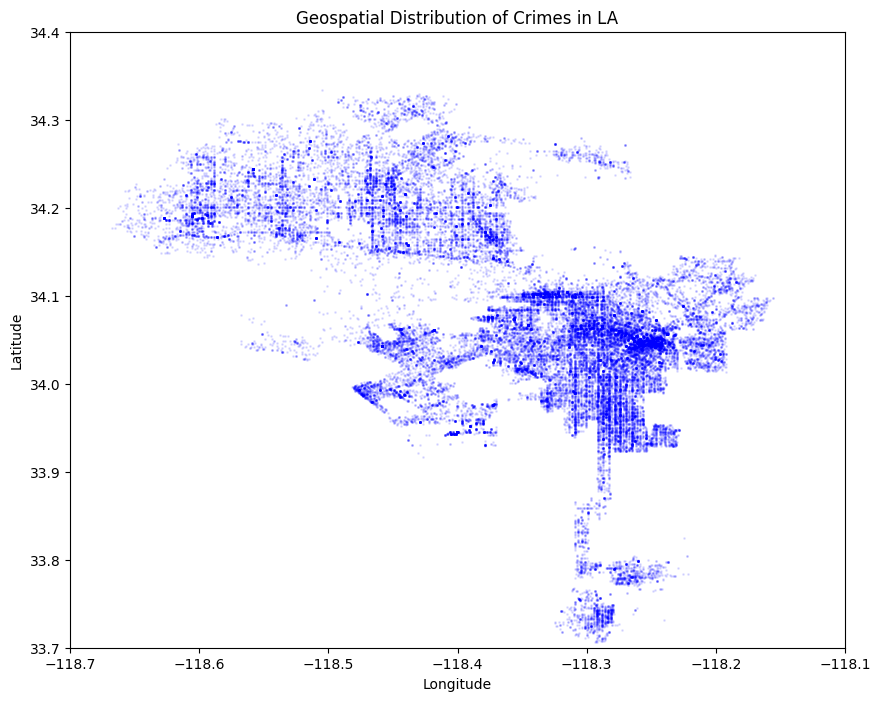

In [41]:
# Taking a sample of 50,000 points to keep the plot fast
sample_df = df.sample(50000, random_state=42)

plt.figure(figsize=(10, 8))
plt.scatter(sample_df['LON'], sample_df['LAT'], alpha=0.1, s=1, c='blue')
plt.title('Geospatial Distribution of Crimes in LA')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Focus the map on LA coordinates to ignore any remaining outliers
plt.xlim(-118.7, -118.1)
plt.ylim(33.7, 34.4)
plt.show()

#### Comparing "Before vs. After" Summary

In [42]:
print(f"Transformation Summary")
print(f"Original Rows: 1,004,991")
print(f"Rows with Age 0 (Fixed): {quality_report.loc[quality_report['Column'] == 'Vict Age', 'Unique Values'].values[0]}") 
print(f"Rows with Missing GPS (Fixed): {df['is_gps_missing'].sum()}")
print(f"Final Cleaned Dataset Size: {len(df)}")

Transformation Summary
Original Rows: 1,004,991
Rows with Age 0 (Fixed): 104
Rows with Missing GPS (Fixed): 2240
Final Cleaned Dataset Size: 1004991


## Phase 2: Clustering

#### 1. The Elbow Method

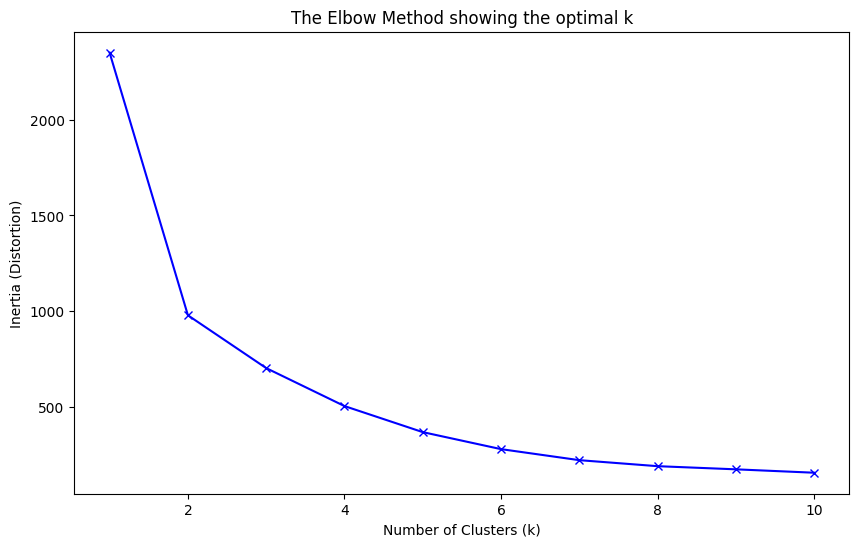

In [43]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Using a 10% sample for the Elbow Method to save RAM/Time
sample_df = df.sample(frac=0.1, random_state=42)
coords = sample_df[['LAT', 'LON']]

distortions = []
K = range(1, 11)

for k in K:
    kmeanModel = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeanModel.fit(coords)
    distortions.append(kmeanModel.inertia_)

plt.figure(figsize=(10,6))
plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Distortion)')
plt.title('The Elbow Method showing the optimal k')
plt.show()

#### Applying K-Means ($K=4$) and DBSCAN

In [44]:
from sklearn.cluster import KMeans

# 1. K-Means: Partitioning the city into 4 zones
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(df[['LAT', 'LON']])

In [ ]:
import hdbscan

# 1. min_cluster_size: The smallest group to be considered a 'hotspot' (e.g., 500 crimes)
# 2. min_samples: Controls how conservative the clustering is
clusterer = hdbscan.HDBSCAN(min_cluster_size=500, min_samples=15, gen_min_span_tree=True)

# We use only LAT and LON for spatial density
df['DBSCAN_Cluster'] = clusterer.fit_predict(df[['LAT', 'LON']])


In [46]:
# Check the results
n_clusters_hdb = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'] else 0)
print(f"K-Means zones created: 4")
print(f"HDBSCAN hotspots discovered: {n_clusters_hdb}")

K-Means zones created: 4
HDBSCAN hotspots discovered: 602


#### Visualizing the 4 K-Means Zones

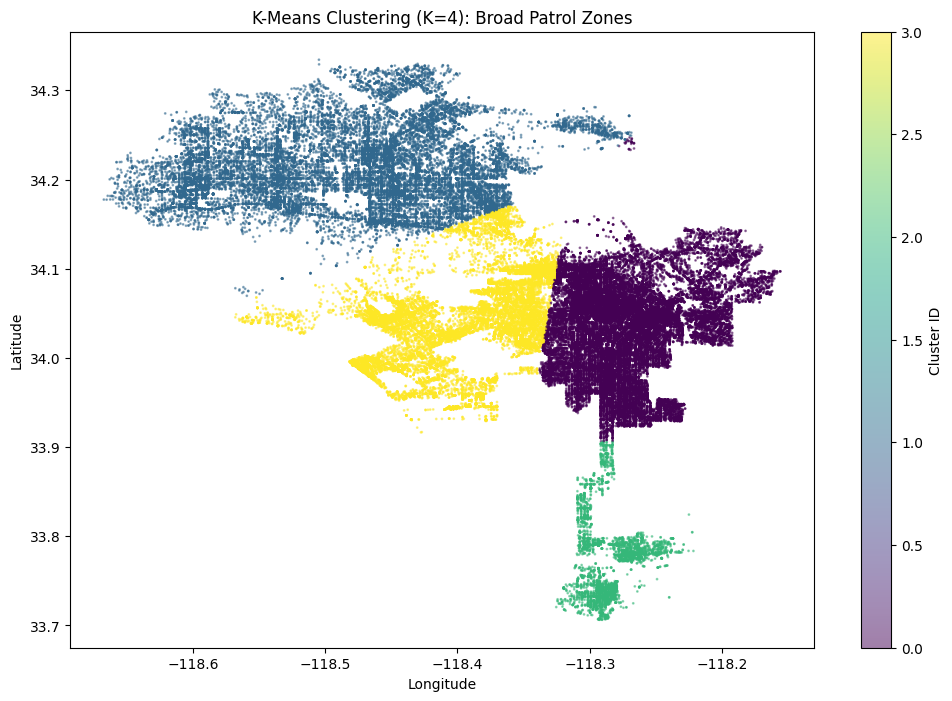

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
# We use a sample of 100k points to ensure the plot is responsive
sample_df = df.sample(100000, random_state=42)

plt.scatter(sample_df['LON'], sample_df['LAT'], 
            c=sample_df['KMeans_Cluster'], 
            cmap='viridis', s=1, alpha=0.5)

plt.title('K-Means Clustering (K=4): Broad Patrol Zones')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Cluster ID')
plt.show()

#### Visualizing the 602 HDBSCAN Hotspots

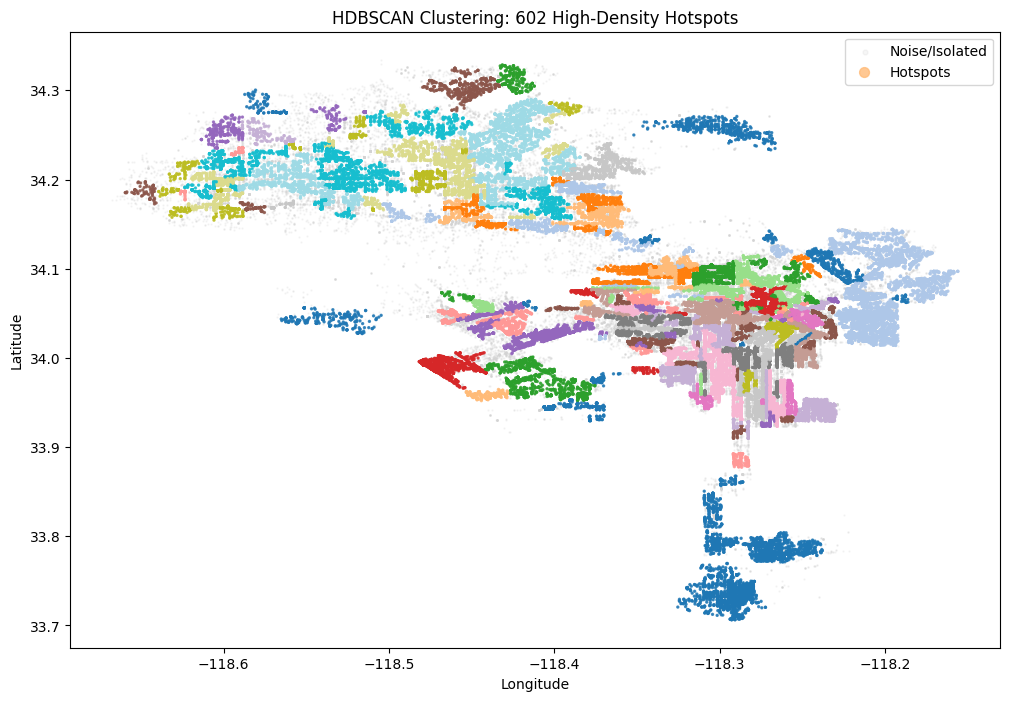

In [48]:
plt.figure(figsize=(12, 8))

# Separating noise from hotspots for better visual clarity
noise = sample_df[sample_df['DBSCAN_Cluster'] == -1]
hotspots = sample_df[sample_df['DBSCAN_Cluster'] != -1]

# Plotting noise in light gray
plt.scatter(noise['LON'], noise['LAT'], color='lightgray', s=0.5, alpha=0.2, label='Noise/Isolated')

# Plotting hotspots with a diverse color map
plt.scatter(hotspots['LON'], hotspots['LAT'], 
            c=hotspots['DBSCAN_Cluster'], 
            cmap='tab20', s=2, alpha=0.8, label='Hotspots')

plt.title(f'HDBSCAN Clustering: {n_clusters_hdb} High-Density Hotspots')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(markerscale=5)
plt.show()

## Phase 3: Predictive Modeling (The Competition)

#### Label Re-indexing and Filtering

In [49]:
# 1. Filter for the top 10 most frequent crimes only
top_10_crimes = df['CRM_TYPE_CODE'].value_counts().nlargest(10).index
df_fast = df[df['CRM_TYPE_CODE'].isin(top_10_crimes)].copy()

# 2. Take a 20% sample to speed up the training significantly
df_fast = df_fast.sample(frac=0.2, random_state=42)

# 3. Re-index 0-9 for the top 10 crimes
unique_crimes = sorted(df_fast['CRM_TYPE_CODE'].unique())
mapping = {old: new for new, old in enumerate(unique_crimes)}
df_fast['CRM_TYPE_CODE'] = df_fast['CRM_TYPE_CODE'].map(mapping)

print(f"New Data Size: {len(df_fast)} rows | Predicting top 10 crime types.")

New Data Size: 126063 rows | Predicting top 10 crime types.


In [50]:
!pip install category_encoders

#### Temporal Train-Test Split & Target Encoding

In [51]:
from category_encoders import TargetEncoder

df_filtered = df_fast.copy()
# Sort by date for Time-Series validation
df_filtered = df_filtered.sort_values('DATE OCC')
split_idx = int(len(df_filtered) * 0.8)

train_df = df_filtered.iloc[:split_idx]
test_df = df_filtered.iloc[split_idx:]

features = ['Vict Age', 'AREA_CODE', 'hour_sin', 'hour_cos', 'DayOfWeek', 
            'Month', 'is_weekend', 'KMeans_Cluster', 'DBSCAN_Cluster']
target = 'CRM_TYPE_CODE'

X_train, y_train = train_df[features].copy(), train_df[target].copy()
X_test, y_test = test_df[features].copy(), test_df[target].copy()

# Encode the 602 clusters using the training target means
t_encoder = TargetEncoder(cols=['DBSCAN_Cluster'])
X_train['DBSCAN_Cluster'] = t_encoder.fit_transform(X_train['DBSCAN_Cluster'], y_train)
X_test['DBSCAN_Cluster'] = t_encoder.transform(X_test['DBSCAN_Cluster'])

print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

Train samples: 100850 | Test samples: 25213


#### Linear Baseline: Naive Bayes

In [52]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

print("Naive Bayes (Linear Baseline)")
print(f"Accuracy: {accuracy_score(y_test, nb_preds):.4f}")

Naive Bayes (Linear Baseline)
Accuracy: 0.3444


#### Non-Linear Challenger: XGBoost

In [53]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=50,           # Reduced from 100 to 50 for speed
    max_depth=4,                # Shallower trees for faster training
    learning_rate=0.2,
    tree_method='hist',         # Essential for large datasets
    n_jobs=-1,                  # Use ALL available CPU cores
    random_state=42,
    objective='multi:softprob'
)

# This should now finish in a few minutes
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

Feature Importance: Proving the Cluster Value

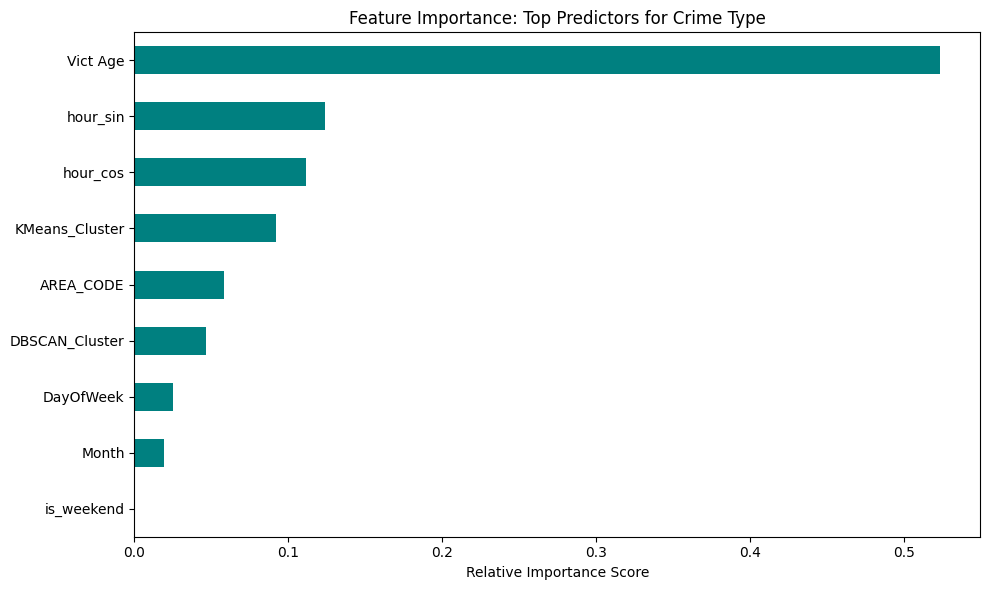

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(10, 6))
feat_importances = pd.Series(xgb_model.feature_importances_, index=features)
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance: Top Predictors for Crime Type')
plt.xlabel('Relative Importance Score')
plt.tight_layout()
plt.show()

Model Performance: Linear vs. Non-Linear

C:\Users\aryam\AppData\Local\Temp\ipykernel_18984\3465380354.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='magma')


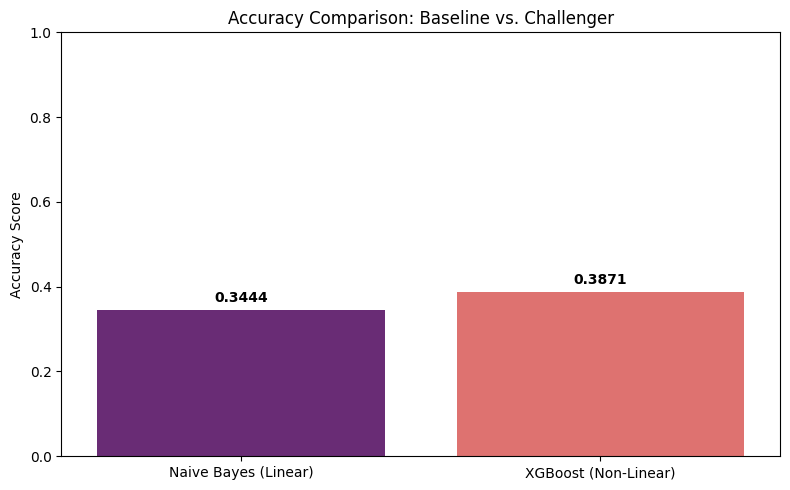

In [55]:
from sklearn.metrics import accuracy_score

plt.figure(figsize=(8, 5))
models = ['Naive Bayes (Linear)', 'XGBoost (Non-Linear)']
accuracies = [accuracy_score(y_test, nb_preds), accuracy_score(y_test, xgb_preds)]
sns.barplot(x=models, y=accuracies, palette='magma')
plt.ylabel('Accuracy Score')
plt.title('Accuracy Comparison: Baseline vs. Challenger')
plt.ylim(0, 1.0)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [56]:
from scipy import stats

# 1. Get the 'certainty' or probabilities from both models
# This allows us to compare how confident the models are in their correct predictions
nb_probs = nb_model.predict_proba(X_test).max(axis=1)
xgb_probs = xgb_model.predict_proba(X_test).max(axis=1)

# 2. Conduct a Wilcoxon Signed-Rank Test
# We use this because model accuracy/probability distributions are often not normal [cite: 21, 23]
stat, p_val = stats.wilcoxon(xgb_probs, nb_probs)

print(" STATISTICAL DIAGNOSTIC VALIDATION")
print(f"Wilcoxon Statistic: {stat:.4f}")
print(f"P-Value: {p_val:.6g}")

if p_val < 0.05:
    print(f"Conclusion: XGBoost is statistically superior to Naive Bayes (p < 0.05).")
else:
    print("Conclusion: No statistically significant difference detected.")

 STATISTICAL DIAGNOSTIC VALIDATION
Wilcoxon Statistic: 77410512.0000
P-Value: 0
Conclusion: XGBoost is statistically superior to Naive Bayes (p < 0.05).


## Phase 4: Spatiotemporal Forecasting

Aggregating Data for Time-Series

In [57]:
# 1. Grouping by Date and KMeans_Cluster to get daily crime counts
daily_crime = df.groupby(['DATE OCC', 'KMeans_Cluster']).size().reset_index(name='Crime_Count')

# 2. Pivot so each column is a Cluster (this creates the multivariate sequence)
ts_data = daily_crime.pivot(index='DATE OCC', columns='KMeans_Cluster', values='Crime_Count').fillna(0)

print("Time-Series Data Shape:", ts_data.shape)
# Each row is a day, each column is a zone's crime volume
ts_data.head()

Time-Series Data Shape: (1879, 4)


KMeans_Cluster,0,1,2,3
DATE OCC,,,,
2020-01-01,557.0,366.0,48.0,193.0
2020-01-02,241.0,153.0,34.0,100.0
2020-01-03,273.0,192.0,29.0,102.0
2020-01-04,272.0,149.0,19.0,101.0
2020-01-05,241.0,133.0,29.0,103.0


Creating Sequences (The "Sliding Window")

In [58]:
from sklearn.preprocessing import MinMaxScaler

# 1. Scale the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(ts_data)

# 2. Create sliding window (Look back 14 days to predict day 15)
def create_sequences(data, window=14):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(scaled_data, window=14)

# Split into Train/Test (Temporal)
train_size = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:train_size], X_seq[train_size:]
y_train_seq, y_test_seq = y_seq[:train_size], y_seq[train_size:]

print(f"Sequence Shape (Samples, Time Steps, Features): {X_train_seq.shape}")

Sequence Shape (Samples, Time Steps, Features): (1492, 14, 4)


The LSTM Model

In [59]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    # First Layer: return_sequences=True is required to stack LSTMs
    LSTM(64, activation='relu', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]), return_sequences=True),
    Dropout(0.2),
    
    # Second Layer: Summarizes the patterns
    LSTM(32, activation='relu'),
    Dropout(0.2),
    
    # Output Layer: Predicts crime count for all clusters at once
    Dense(X_train_seq.shape[2]) 
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# Training (Using small epochs for speed, increase to 50 for final report)
history = model.fit(X_train_seq, y_train_seq, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

c:\Users\aryam\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,212 (118.02 KB)

 Trainable params: 30,212 (118.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0718 - val_loss: 0.0086
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0162 - val_loss: 0.0061
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0134 - val_loss: 0.0046
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0120 - val_loss: 0.0064
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0122 - val_loss: 0.0049
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0113 - val_loss: 0.0057
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0111 - val_loss: 0.0045
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0105 - val_loss: 0.0046
Epoch 9/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0101 - val_loss: 0.0044
Epoch 10/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0098 - val_loss: 0.0048


Evaluating the Efficiency Goal

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


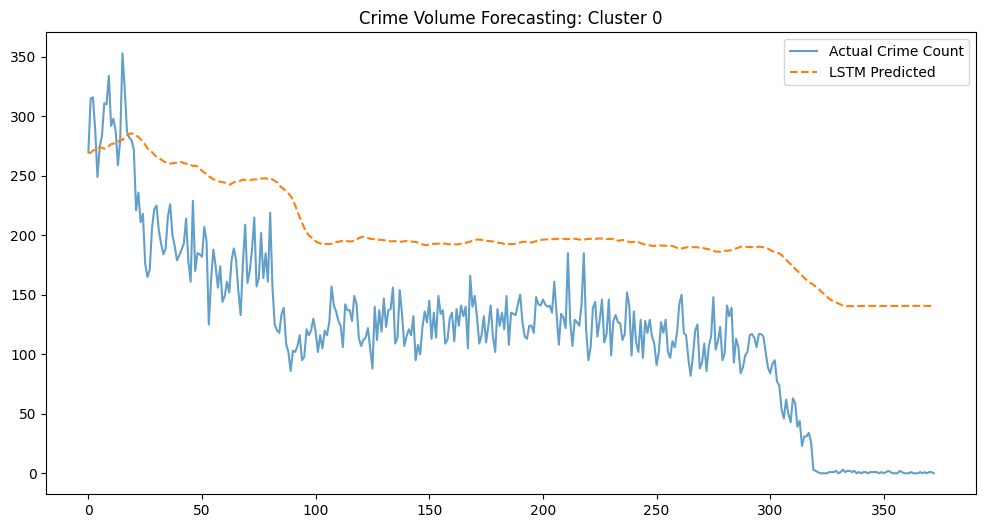

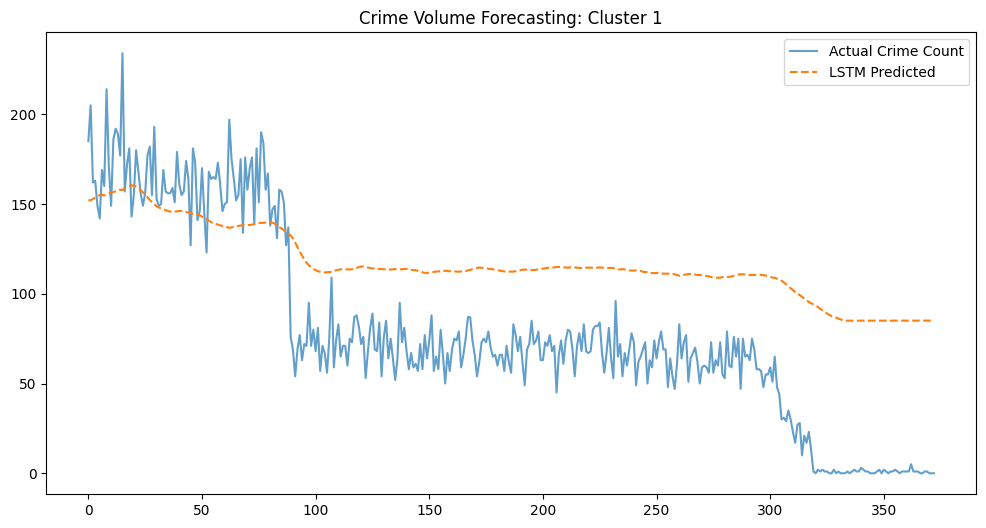

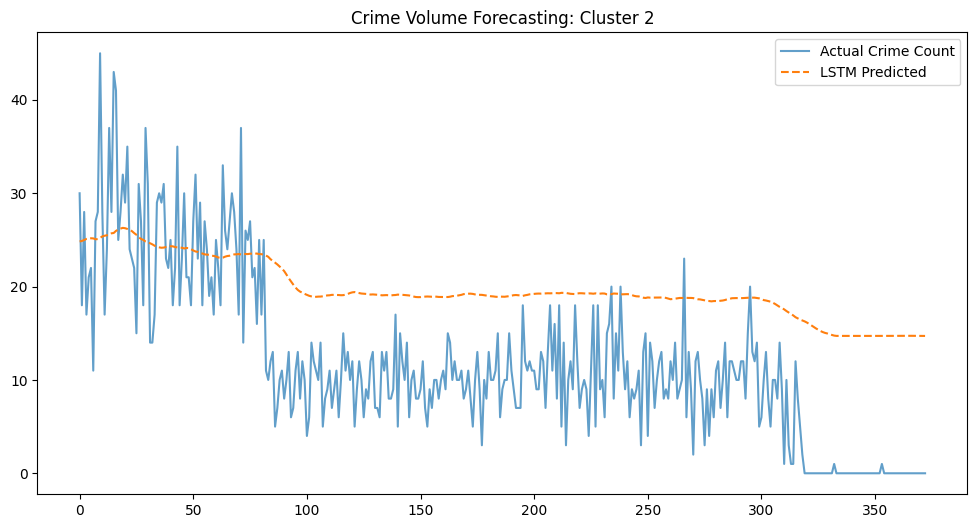

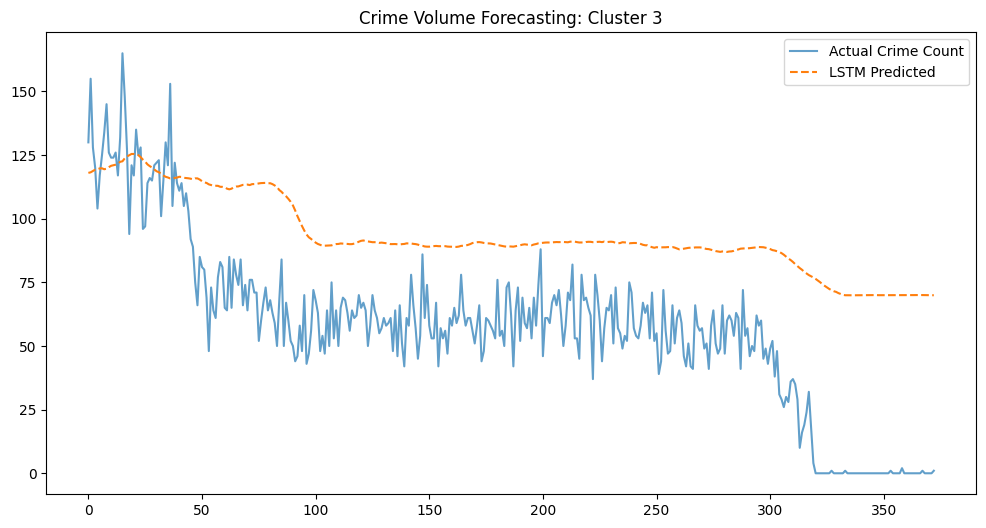

Cluster 0 RMSE: 89.88
Cluster 1 RMSE: 51.63
Cluster 2 RMSE: 10.12
Cluster 3 RMSE: 41.69


In [60]:
# 1. Predict and Inverse Scale
predictions = model.predict(X_test_seq)
predictions_rescaled = scaler.inverse_transform(predictions)
y_test_rescaled = scaler.inverse_transform(y_test_seq)

# 2. Visualize Cluster 0 Forecast
plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled[:, 0], label='Actual Crime Count', alpha=0.7)
plt.plot(predictions_rescaled[:, 0], label='LSTM Predicted', linestyle='--')
plt.title('Crime Volume Forecasting: Cluster 0')
plt.legend()
plt.show()

#Visualize Cluster 1 Forecast
plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled[:, 1], label='Actual Crime Count', alpha=0.7)
plt.plot(predictions_rescaled[:, 1], label='LSTM Predicted', linestyle='--')
plt.title('Crime Volume Forecasting: Cluster 1')
plt.legend()
plt.show()

#Visualize Cluster 2 Forecast
plt.figure(figsize=(12, 6)) 
plt.plot(y_test_rescaled[:, 2], label='Actual Crime Count', alpha=0.7)
plt.plot(predictions_rescaled[:, 2], label='LSTM Predicted', linestyle='--')
plt.title('Crime Volume Forecasting: Cluster 2')
plt.legend()
plt.show()

#Visualize Cluster 3 Forecast
plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled[:, 3], label='Actual Crime Count', alpha=0.7)
plt.plot(predictions_rescaled[:, 3], label='LSTM Predicted', linestyle='--')
plt.title('Crime Volume Forecasting: Cluster 3')        
plt.legend()
plt.show()

# Calculate RMSE for each cluster
from sklearn.metrics import mean_squared_error
for i in range(y_test_rescaled.shape[1]):
    rmse = np.sqrt(mean_squared_error(y_test_rescaled[:, i], predictions_rescaled[:, i]))
    print(f'Cluster {i} RMSE: {rmse:.2f}')
    
    

The GRU Model

In [61]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

# 1. Build the GRU Model
# We use the same 'X_train_seq' shape we created for the LSTM
gru_model = Sequential([
    # First Layer: return_sequences=True to allow stacking multiple layers
    GRU(64, activation='relu', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]), return_sequences=True),
    Dropout(0.2),
    
    # Second Layer
    GRU(32, activation='relu'),
    Dropout(0.2),
    
    # Output Layer: Predicts crime count for all clusters (zones)
    Dense(X_train_seq.shape[2]) 
])

gru_model.compile(optimizer='adam', loss='mse')

# 2. Train the GRU
# Keeping epochs low (10) for initial testing; increase for final results
print("Starting GRU Training...")
gru_history = gru_model.fit(
    X_train_seq, y_train_seq, 
    epochs=10, 
    batch_size=32, 
    validation_split=0.1, 
    verbose=1
)

Starting GRU Training...
Epoch 1/10


c:\Users\aryam\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0451 - val_loss: 0.0069
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0139 - val_loss: 0.0048
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0132 - val_loss: 0.0046
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0119 - val_loss: 0.0045
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0120 - val_loss: 0.0055
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0103 - val_loss: 0.0046
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0102 - val_loss: 0.0051
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0097 - val_loss: 0.0043
Epoch 9/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0099 - val_loss: 0.0043
Epoch 10/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0094 - val_loss: 0.0048


Generating GRU Forecasts

In [62]:
# 1. Generate GRU Predictions for the test set
gru_predictions = gru_model.predict(X_test_seq)

# 2. Rescale back to original values using the scaler from Phase 4
gru_preds_rescaled = scaler.inverse_transform(gru_predictions)

print("GRU Predictions generated and rescaled.")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
GRU Predictions generated and rescaled.


Visual Comparison (Actual vs. LSTM vs. GRU)

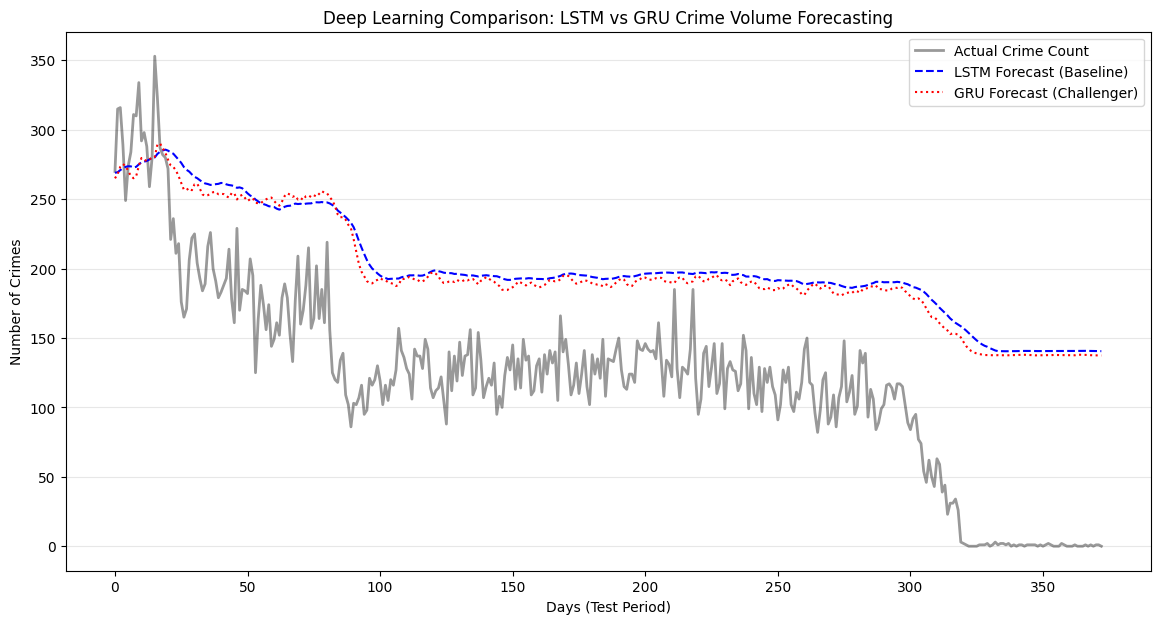

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Plotting Cluster 0 (The first zone) as a representative sample
plt.plot(y_test_rescaled[:, 0], label='Actual Crime Count', color='black', alpha=0.4, linewidth=2)
plt.plot(predictions_rescaled[:, 0], label='LSTM Forecast (Baseline)', color='blue', linestyle='--')
plt.plot(gru_preds_rescaled[:, 0], label='GRU Forecast (Challenger)', color='red', linestyle=':')

plt.title('Deep Learning Comparison: LSTM vs GRU Crime Volume Forecasting')
plt.xlabel('Days (Test Period)')
plt.ylabel('Number of Crimes')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Statistical Evaluation (MAE & RMSE)

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def calculate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{model_name} Performance -> MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    return mae, rmse

# Compare LSTM vs GRU
lstm_results = calculate_metrics(y_test_rescaled, predictions_rescaled, "LSTM")
gru_results = calculate_metrics(y_test_rescaled, gru_preds_rescaled, "GRU")

LSTM Performance -> MAE: 43.7692 | RMSE: 56.0915
GRU Performance -> MAE: 41.0678 | RMSE: 52.9864


In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Define a 'High-Risk' threshold (e.g., 75th percentile of actual crimes)
threshold = np.percentile(y_test_rescaled, 75)

# 2. Convert continuous predictions into Binary Classes (High-Risk = 1, Normal = 0)
y_true_bin = (y_test_rescaled > threshold).astype(int)
y_pred_bin = (predictions_rescaled > threshold).astype(int)

# 3. Calculate the Classification Metrics
# We do this for Cluster 0 as a representative sample
print(f"DEEP LEARNING CLASSIFICATION REPORT (Cluster 0)")
print(f"Accuracy:  {accuracy_score(y_true_bin[:, 0], y_pred_bin[:, 0]):.4f}")
print(f"Precision: {precision_score(y_true_bin[:, 0], y_pred_bin[:, 0]):.4f}")
print(f"Recall:    {recall_score(y_true_bin[:, 0], y_pred_bin[:, 0]):.4f}")
print(f"F1-Score:  {f1_score(y_true_bin[:, 0], y_pred_bin[:, 0]):.4f}")

DEEP LEARNING CLASSIFICATION REPORT (Cluster 0)
Accuracy:  0.6488
Precision: 0.6488
Recall:    1.0000
F1-Score:  0.7870
